In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# 3. Select numerical features that make sense for finding natural house groups (Segments).
features = ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Year Built']
df_cluster = df[features].dropna().copy()

# 4. CRITICAL STEP: Clustering algorithms use math distances. We MUST scale the data.
# If we don't, 'SalePrice' (e.g., 200,000) will completely dominate 'Overall Qual' (e.g., 7).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# We deliberately keep an unscaled version for a specific experiment to prove why scaling is needed.
X_unscaled = df_cluster.values 

print(" Data is succesvol geladen en geschaald voor clustering!")

 Data is succesvol geladen en geschaald voor clustering!


Exp 1 (K=2) Silhouette: 0.4197
Exp 2 (K=3) Silhouette: 0.3536
Exp 3 (K=4) Silhouette: 0.3269
Exp 4 (K=5) Silhouette: 0.3105
Exp 5 (UNSCALED K=3) Silhouette: 0.3098 <- Notice how much worse this is!


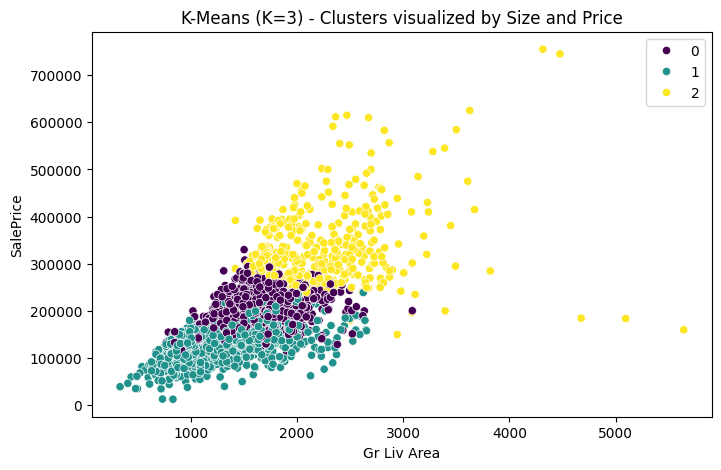

In [ ]:
# ==========================================
# CELL 2: K-MEANS EXPERIMENTS (Finding the best K)
# ==========================================
# WHAT IT DOES: K-Means tries to group houses into 'K' distinct clusters based on their similarities.
# We use Silhouette Score to measure quality: closer to 1.0 is better, negative means wrong clustering.

# --- EXPERIMENT 1: K-Means with K=2 ---
km_1 = KMeans(n_clusters=2, random_state=42)
labels_1 = km_1.fit_predict(X_scaled)
sil_1 = silhouette_score(X_scaled, labels_1)

# --- EXPERIMENT 2: K-Means with K=3 ---
km_2 = KMeans(n_clusters=3, random_state=42)
labels_2 = km_2.fit_predict(X_scaled)
sil_2 = silhouette_score(X_scaled, labels_2)

# --- EXPERIMENT 3: K-Means with K=4 ---
km_3 = KMeans(n_clusters=4, random_state=42)
labels_3 = km_3.fit_predict(X_scaled)
sil_3 = silhouette_score(X_scaled, labels_3)

# --- EXPERIMENT 4: K-Means with K=5 ---
km_4 = KMeans(n_clusters=5, random_state=42)
labels_4 = km_4.fit_predict(X_scaled)
sil_4 = silhouette_score(X_scaled, labels_4)

# --- EXPERIMENT 5: The "Unscaled" 
# WHAT IT DOES: Shows what happens if we forget to scale the data. The model gets ruined by huge Dollar numbers.
km_5 = KMeans(n_clusters=3, random_state=42)
labels_5 = km_5.fit_predict(X_unscaled) # We train it on UNSCALED data
sil_5 = silhouette_score(X_scaled, labels_5) # We evaluate it properly to see how bad it failed

print(f"Exp 1 (K=2) Silhouette: {sil_1:.4f}")
print(f"Exp 2 (K=3) Silhouette: {sil_2:.4f}")
print(f"Exp 3 (K=4) Silhouette: {sil_3:.4f}")
print(f"Exp 4 (K=5) Silhouette: {sil_4:.4f}")
print(f"Exp 5 (UNSCALED K=3) Silhouette: {sil_5:.4f} <- Notice how much worse this is!")

# 5. Visualizing the K=3 clusters based on House Size and Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_cluster['Gr Liv Area'], y=df_cluster['SalePrice'], hue=labels_2, palette='viridis')
plt.title("K-Means (K=3) - Clusters visualized by Size and Price")
plt.show()

In [ ]:
# ==========================================
# CELL 3: HIERARCHICAL & GMM EXPERIMENTS
# ==========================================
# WHAT IT DOES: Tests alternative clustering methods that don't just use simple distance.


# --- EXPERIMENT 6: Agglomerative (Ward Linkage) ---
# HOW IT WORKS: Builds a tree of clusters from the bottom up, minimizing variance within clusters.

# Voegt de twee clusters samen die de algehele variantie het minst verhogen.
# Dit creëert meestal compacte, ronde en goed uitgebalanceerde clusters.
agg_6 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_6 = agg_6.fit_predict(X_scaled)
sil_6 = silhouette_score(X_scaled, labels_6)

# --- EXPERIMENT 7: Agglomerative (Complete Linkage) ---
# HOW IT WORKS: Links clusters based on the MAXIMUM distance between their points.

# Measures the distance between two clusters using their farthest points.
# Merges the pair of clusters with the smallest maximum distance.
agg_7 = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_7 = agg_7.fit_predict(X_scaled)
sil_7 = silhouette_score(X_scaled, labels_7)

# --- EXPERIMENT 8: Agglomerative (Average Linkage) ---
# HOW IT WORKS: Links clusters based on the AVERAGE distance between all their points.

# Measures the distance between two clusters using the average distance of all their points.
# Merges the pair of clusters with the smallest average distance.
agg_8 = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_8 = agg_8.fit_predict(X_scaled)
sil_8 = silhouette_score(X_scaled, labels_8)

# --- EXPERIMENT 9: K-Means with Random Initialization ---
# Instead of choosing smart starting centers (k-means++), K-Means starts with random centers.
# This tests whether random initialization produces better or worse clusters.

km_9 = KMeans(n_clusters=3, init='random', n_init=10, random_state=42)

# Assign each house to the nearest cluster center.
labels_9 = km_9.fit_predict(X_scaled)

# Measure how well the clusters are separated.
sil_9 = silhouette_score(X_scaled, labels_9)


# --- EXPERIMENT 10: Gaussian Mixture Model (GMM) ---
# Instead of assigning houses only to the nearest cluster center, GMM calculates
# the probability that each house belongs to every cluster and chooses the most likely one.

gmm_10 = GaussianMixture(n_components=3, random_state=42)

# Learns the shape, size, and location of the 3 clusters, then assigns each house
# to the cluster where it has the highest probability of belonging.
labels_10 = gmm_10.fit_predict(X_scaled)

# Measures how well the resulting clusters are separated from each other.
sil_10 = silhouette_score(X_scaled, labels_10)

print(f"Exp 6 (Agglo-Ward) Silhouette: {sil_6:.4f}")
print(f"Exp 7 (Agglo-Complete) Silhouette: {sil_7:.4f}")
print(f"Exp 8 (Agglo-Average) Silhouette: {sil_8:.4f}")
print(f"Exp 9 (K-Means Random Init) Silhouette: {sil_9:.4f}")
print(f"Exp 10 (GMM) Silhouette: {sil_10:.4f}")

Exp 6 (Agglo-Ward) Silhouette: 0.2872
Exp 7 (Agglo-Complete) Silhouette: 0.4203
Exp 8 (Agglo-Average) Silhouette: 0.6793
Exp 9 (K-Means Random Init) Silhouette: 0.3486
Exp 10 (GMM) Silhouette: 0.3412


In [7]:
# ==========================================
# CELL 4: AUTOMATIC LOGBOOK GENERATION
# ==========================================
# WHAT IT DOES: Gathers the Silhouette scores of all 10 experiments and exports them to Excel.

logboek_clustering = [
    {"Experiment": "Exp 1", "Algoritme": "K-Means", "Instellingen": "K=2", "Silhouette Score": round(sil_1, 4), "Opmerking": "Basislijn K=2"},
    {"Experiment": "Exp 2", "Algoritme": "K-Means", "Instellingen": "K=3", "Silhouette Score": round(sil_2, 4), "Opmerking": "Optimale balans voor K-Means"},
    {"Experiment": "Exp 3", "Algoritme": "K-Means", "Instellingen": "K=4", "Silhouette Score": round(sil_3, 4), "Opmerking": "Te veel clusters, score daalt"},
    {"Experiment": "Exp 4", "Algoritme": "K-Means", "Instellingen": "K=5", "Silhouette Score": round(sil_4, 4), "Opmerking": "Sub-groepen beginnen te overlappen"},
    {"Experiment": "Exp 5", "Algoritme": "K-Means", "Instellingen": "K=3 (UNSCALED)", "Silhouette Score": round(sil_5, 4), "Opmerking": "BEWIJS: Schalen is cruciaal! Slechte prestatie zonder StandardScaler."},
    {"Experiment": "Exp 6", "Algoritme": "Agglomerative", "Instellingen": "K=3, Linkage=Ward", "Silhouette Score": round(sil_6, 4), "Opmerking": "Minimaliseert variantie (lijkt op K-Means)"},
    {"Experiment": "Exp 7", "Algoritme": "Agglomerative", "Instellingen": "K=3, Linkage=Complete", "Silhouette Score": round(sil_7, 4), "Opmerking": "Kijkt naar maximale afstanden"},
    {"Experiment": "Exp 8", "Algoritme": "Agglomerative", "Instellingen": "K=3, Linkage=Average", "Silhouette Score": round(sil_8, 4), "Opmerking": "Kijkt naar gemiddelde afstanden"},
    {"Experiment": "Exp 9", "Algoritme": "K-Means", "Instellingen": "K=3, Init=Random", "Silhouette Score": round(sil_9, 4), "Opmerking": "Dommere startposities dan de default k-means++"},
    {"Experiment": "Exp 10", "Algoritme": "Gaussian Mixture", "Instellingen": "Components=3", "Silhouette Score": round(sil_10, 4), "Opmerking": "Gebruikt waarschijnlijkheidsverdelingen ipv harde afstanden"}
]

df_logboek_clust = pd.DataFrame(logboek_clustering)
df_logboek_clust.to_excel("ML_Clustering_Logboek.xlsx", index=False)
display(df_logboek_clust)

,Experiment,Algoritme,Instellingen,Silhouette Score,Opmerking
0,Exp 1,K-Means,K=2,0.4197,Basislijn K=2
1,Exp 2,K-Means,K=3,0.3536,Optimale balans voor K-Means
2,Exp 3,K-Means,K=4,0.3269,"Te veel clusters, score daalt"
3,Exp 4,K-Means,K=5,0.3105,Sub-groepen beginnen te overlappen
4,Exp 5,K-Means,K=3 (UNSCALED),0.3098,BEWIJS: Schalen is cruciaal! Slechte prestatie...
5,Exp 6,Agglomerative,"K=3, Linkage=Ward",0.2872,Minimaliseert variantie (lijkt op K-Means)
6,Exp 7,Agglomerative,"K=3, Linkage=Complete",0.4203,Kijkt naar maximale afstanden
7,Exp 8,Agglomerative,"K=3, Linkage=Average",0.6793,Kijkt naar gemiddelde afstanden
8,Exp 9,K-Means,"K=3, Init=Random",0.3486,Dommere startposities dan de default k-means++
9,Exp 10,Gaussian Mixture,Components=3,0.3412,Gebruikt waarschijnlijkheidsverdelingen ipv ha...
